In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [71]:
data = pd.read_csv("Datasets/placement.csv")
data.sample(5)

,Unnamed: 0,cgpa,iq,placement
35,35,6.8,90.0,1
40,40,4.9,134.0,0
9,9,5.1,66.0,0
45,45,6.0,66.0,1
88,88,4.4,149.0,0


C:\Users\sunil\AppData\Local\Temp\ipykernel_9940\4169335046.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['cgpa'], kde=True)
C:\Users\sunil\AppData\Local\Temp\ipykernel_9940\4169335046.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['iq'], kde=True)


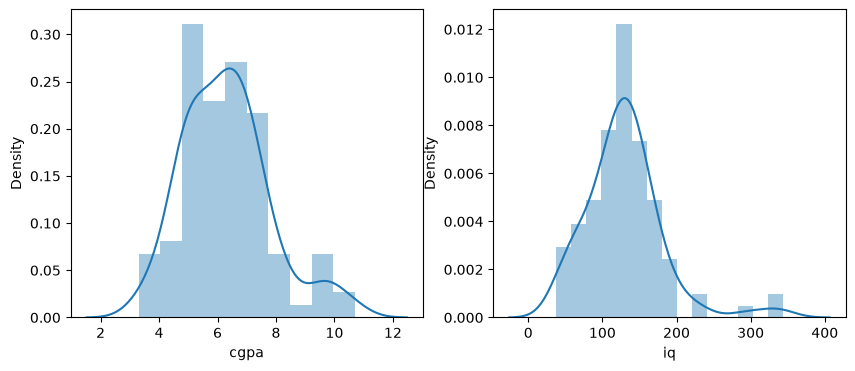

In [72]:
plt.figure(figsize=(10, 4))
plt.subplot(1,2,1)
sns.distplot(data['cgpa'], kde=True)

plt.subplot(1, 2, 2)
sns.distplot(data['iq'], kde=True)

plt.show()

In [73]:
data['cgpa'].describe()

count    100.000000
mean       6.301000
std        1.488101
min        3.300000
25%        5.175000
50%        6.150000
75%        7.000000
max       10.700000
Name: cgpa, dtype: float64

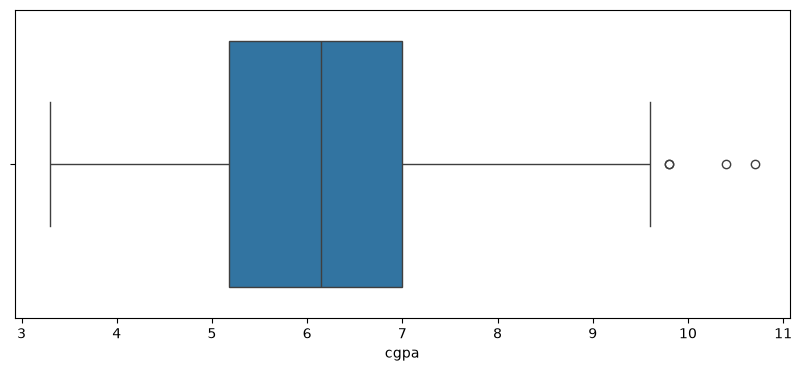

In [74]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=data['cgpa'])

plt.show()

In [75]:
# Finding the IQR
percentile25 = data['cgpa'].quantile(0.25)
percentile75 = data['cgpa'].quantile(0.75)

In [76]:
percentile25, percentile75

(np.float64(5.175), np.float64(7.0))

In [77]:
iqr = percentile75 - percentile25
iqr

np.float64(1.8250000000000002)

In [78]:
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr

In [79]:
print("Upper limit",upper_limit)
print("Lower limit",lower_limit)

Upper limit 9.7375
Lower limit 2.4374999999999996


In [80]:
data[data['cgpa'] > upper_limit]

,Unnamed: 0,cgpa,iq,placement
36,36,10.7,140.0,0
41,41,10.4,114.0,0
51,51,9.8,141.0,0
59,59,9.8,292.0,0


In [81]:
data[data['cgpa'] < lower_limit]

,Unnamed: 0,cgpa,iq,placement


In [82]:
new_data = data[data['cgpa'] < upper_limit]

In [83]:
new_data.shape

(96, 4)

C:\Users\sunil\AppData\Local\Temp\ipykernel_9940\3199196404.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['cgpa'])
C:\Users\sunil\AppData\Local\Temp\ipykernel_9940\3199196404.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_data['cgpa'])


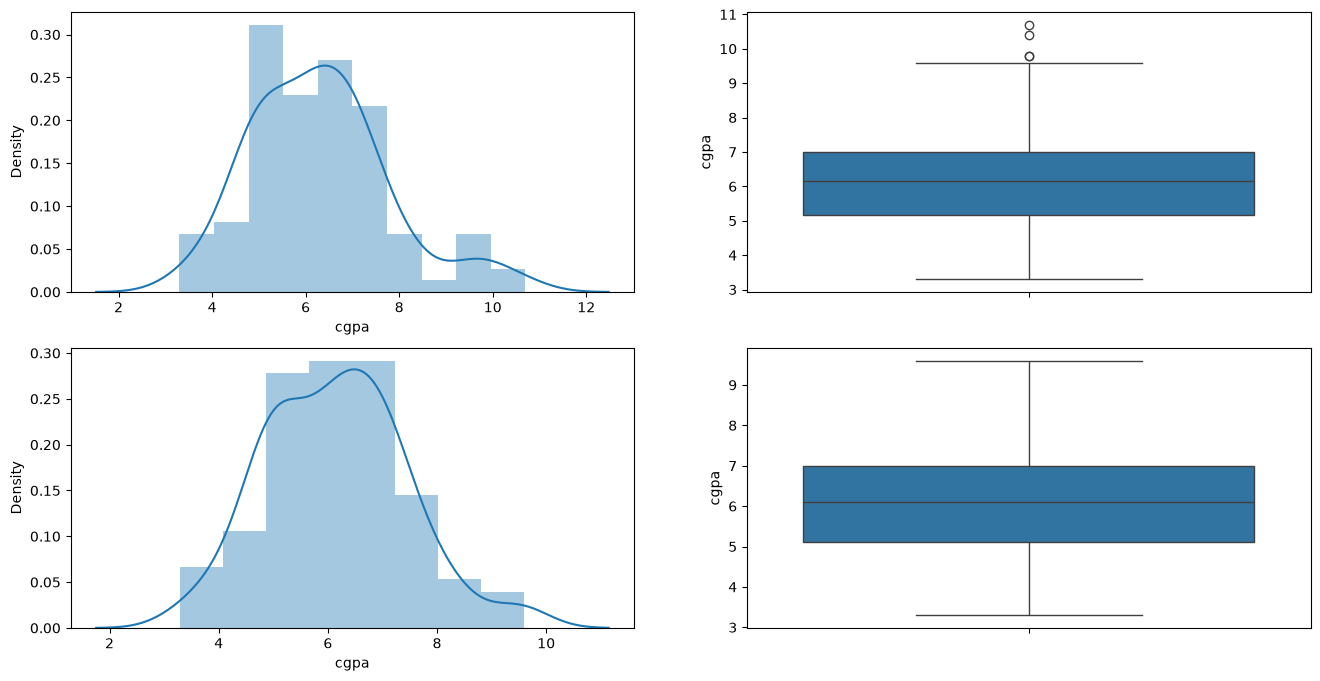

In [84]:
# Comparing

plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(data['cgpa'])

plt.subplot(2,2,2)
sns.boxplot(data['cgpa'])

plt.subplot(2,2,3)
sns.distplot(new_data['cgpa'])

plt.subplot(2,2,4)
sns.boxplot(new_data['cgpa'])

plt.show()

In [85]:
new_df_cap = data.copy()

new_df_cap['cgpa'] = np.where(
    new_df_cap['cgpa'] > upper_limit,
    upper_limit,
    np.where(
        new_df_cap['cgpa'] < lower_limit,
        lower_limit,
        new_df_cap['cgpa']
    )
)

In [88]:
# np.where(condition, True, False)

In [89]:
new_df_cap.shape

(100, 4)

C:\Users\sunil\AppData\Local\Temp\ipykernel_9940\1599116790.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['cgpa'])
C:\Users\sunil\AppData\Local\Temp\ipykernel_9940\1599116790.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df_cap['cgpa'])


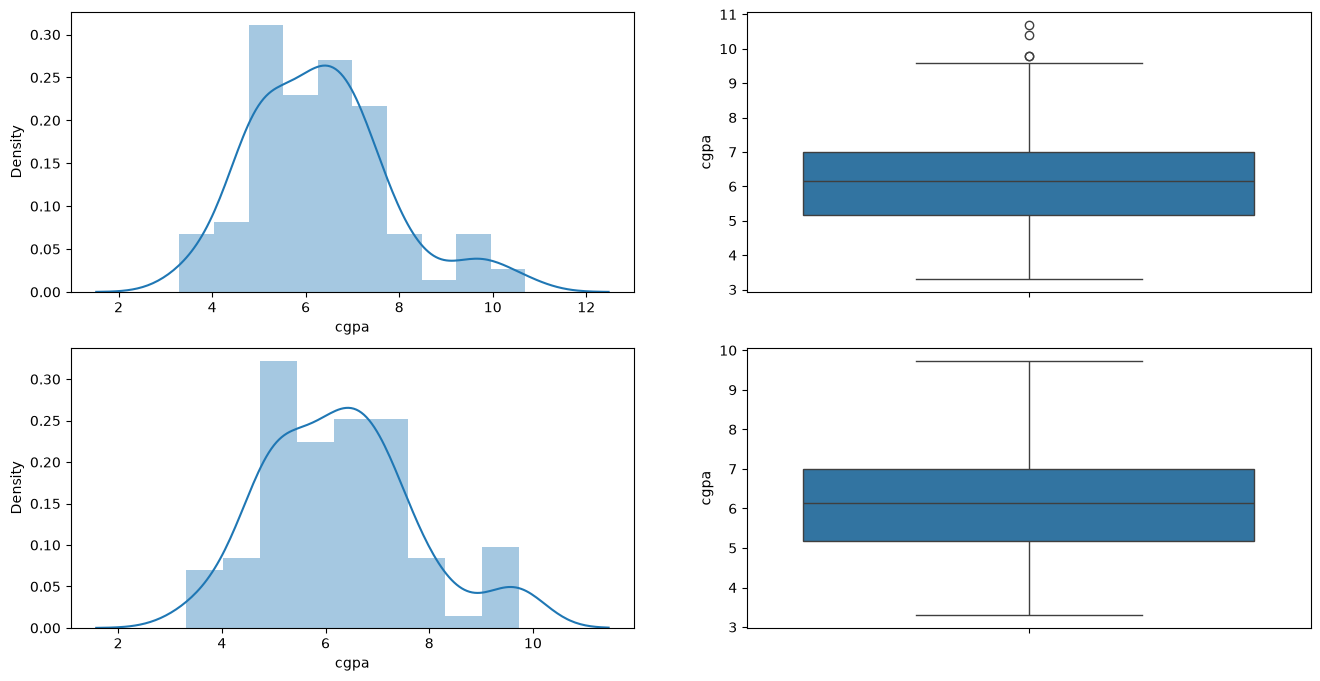

In [90]:
# Comparing

plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(data['cgpa'])

plt.subplot(2,2,2)
sns.boxplot(data['cgpa'])

plt.subplot(2,2,3)
sns.distplot(new_df_cap['cgpa'])

plt.subplot(2,2,4)
sns.boxplot(new_df_cap['cgpa'])

plt.show()